In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

from myDataset import *
from ArchitectureMethods import *
from MetricMethods import *

In [2]:
import torchvision.models as models

# Loads model from .pth file
os.chdir('/user/HS401/ob00564/Documents/COM3001/JAFFE/Transfer Learning')

emotionTotal = 7

# Loads MobileNetV2 trained model
mobilenet = models.mobilenet_v2(weights = 'DEFAULT')
mobilenet.classifier = torch.nn.Linear(in_features=1280, out_features= emotionTotal)
mobilenet.load_state_dict(torch.load('JAFFE MobileNetV2 copy.pth'))
mobilenet.to('cuda')
mobilenet.eval()

# Loads ResNet18 trained model
resnet18 = models.resnet18(weights = None)
resnet18.fc = nn.Sequential(nn.Linear(resnet18.fc.in_features,emotionTotal))
resnet18.load_state_dict(torch.load('JAFFE ResNet18 copy.pth'))
resnet18.to('cuda')
resnet18.eval()

# Loads ResNet34 trained model
resnet34 = models.resnet34(weights = None)
resnet34.fc = nn.Sequential(nn.Linear(resnet34.fc.in_features,emotionTotal))
resnet34.load_state_dict(torch.load('JAFFE ResNet34 copy.pth'))
resnet34.to('cuda')
resnet34.eval()

from sklearn.metrics import f1_score
from sklearn.metrics import precision_score, recall_score
os.chdir('/user/HS401/ob00564/Documents/COM3001/JAFFE')

print(os.getcwd())
JAFFE_dataset = myDataset(directory = "DATASET/test", transform = test_transform)
JAFFE_loader = DataLoader(JAFFE_dataset, batch_size = 32, shuffle = False)

device = 'cuda'
criterion = nn.CrossEntropyLoss()


/tmp/ipykernel_1601501/441997865.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mobilenet.load_state_dict(torch.load('JAFFE MobileNetV2 copy.pth'))
/tmp/ipykernel_1601

/user/HS401/ob00564/Documents/COM3001/JAFFE


/tmp/ipykernel_1601501/441997865.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet34.load_state_dict(torch.load('JAFFE ResNet34 copy.pth'))


JAFFE SPLIT MobileNetV2
Test Loss: 1.9435, Test Accuracy: 28.57%
              precision    recall  f1-score   support

       Anger     0.0000    0.0000    0.0000         3
     Disgust     0.0000    0.0000    0.0000         3
        Fear     0.4000    0.6667    0.5000         3
   Happiness     0.2308    1.0000    0.3750         3
     Sadness     1.0000    0.3333    0.5000         3
    Surprise     0.0000    0.0000    0.0000         3
     Neurtal     0.0000    0.0000    0.0000         3

    accuracy                         0.2857        21
   macro avg     0.2330    0.2857    0.1964        21
weighted avg     0.2330    0.2857    0.1964        21



/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

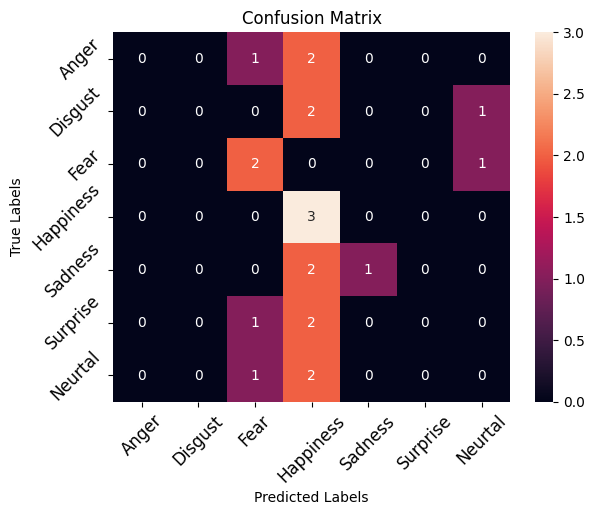

In [3]:
criterion = nn.CrossEntropyLoss()
print('JAFFE SPLIT MobileNetV2')
JAFFE_y_true, JAFFE_y_pred, JAFFE_y_score = test(mobilenet, device, criterion, JAFFE_loader, 'Test')
confusionMatrixPlot(JAFFE_y_true, JAFFE_y_pred)

JAFFE SPLIT ResNet18
Test Loss: 1.8954, Test Accuracy: 14.29%
              precision    recall  f1-score   support

       Anger     0.2000    0.3333    0.2500         3
     Disgust     0.5000    0.3333    0.4000         3
        Fear     1.0000    0.3333    0.5000         3
   Happiness     0.0000    0.0000    0.0000         3
     Sadness     0.0000    0.0000    0.0000         3
    Surprise     0.0000    0.0000    0.0000         3
     Neurtal     0.0000    0.0000    0.0000         3

    accuracy                         0.1429        21
   macro avg     0.2429    0.1429    0.1643        21
weighted avg     0.2429    0.1429    0.1643        21



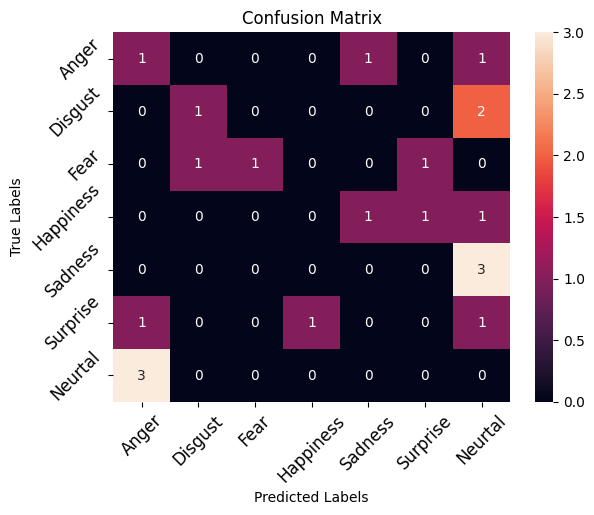

In [4]:
criterion = nn.CrossEntropyLoss()
print('JAFFE SPLIT ResNet18')
JAFFE_y_true, JAFFE_y_pred, JAFFE_y_score = test(resnet18, device, criterion, JAFFE_loader, 'Test')
confusionMatrixPlot(JAFFE_y_true, JAFFE_y_pred)

JAFFE SPLIT ResNet34
Test Loss: 1.9533, Test Accuracy: 19.05%
              precision    recall  f1-score   support

       Anger     0.0000    0.0000    0.0000         3
     Disgust     0.1250    0.3333    0.1818         3
        Fear     0.5000    0.6667    0.5714         3
   Happiness     0.0000    0.0000    0.0000         3
     Sadness     0.0000    0.0000    0.0000         3
    Surprise     0.3333    0.3333    0.3333         3
     Neurtal     0.0000    0.0000    0.0000         3

    accuracy                         0.1905        21
   macro avg     0.1369    0.1905    0.1552        21
weighted avg     0.1369    0.1905    0.1552        21



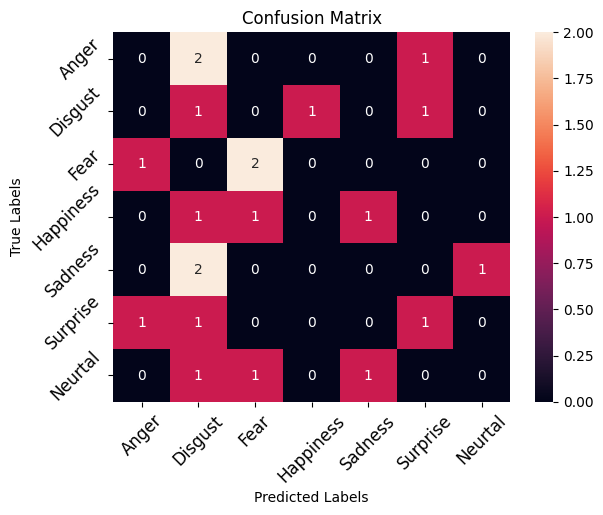

In [5]:
criterion = nn.CrossEntropyLoss()
print('JAFFE SPLIT ResNet34')
JAFFE_y_true, JAFFE_y_pred, JAFFE_y_score = test(resnet34, device, criterion, JAFFE_loader, 'Test')
confusionMatrixPlot(JAFFE_y_true, JAFFE_y_pred)

In [6]:
os.chdir('/user/HS401/ob00564/Documents/COM3001/KDEF')
print(os.getcwd())
kdef_dataset = myDataset(directory = "DATASET/test", transform = test_transform)
kdef_loader = DataLoader(kdef_dataset, batch_size = 32, shuffle = False)

os.chdir('/user/HS401/ob00564/Documents/COM3001/CK+')
print(os.getcwd())
ck_dataset = myDataset(directory = "DATASET/test", transform = test_transform)
ck_loader = DataLoader(ck_dataset, batch_size = 32, shuffle = False)

print(len(kdef_dataset))
print(len(ck_dataset))

device = 'cuda'
criterion = nn.CrossEntropyLoss()

/user/HS401/ob00564/Documents/COM3001/KDEF
/user/HS401/ob00564/Documents/COM3001/CK+
294
93


In [7]:
os.chdir('/user/HS401/ob00564/Documents/COM3001/CK+')

print('CK+ SPLIT MobileNetV2')
ck_y_true, ck_y_pred, ck_y_score = test(mobilenet, device, criterion, ck_loader, 'Test')

print('CK+ SPLIT ResNet18')
ck_y_true, ck_y_pred, ck_y_score = test(resnet18, device, criterion, ck_loader, 'Test')

print('CK+ SPLIT ResNet34')
ck_y_true, ck_y_pred, ck_y_score = test(resnet34, device, criterion, ck_loader, 'Test')

CK+ SPLIT MobileNetV2
Test Loss: 1.9764, Test Accuracy: 7.53%
CK+ SPLIT ResNet18
Test Loss: 2.3776, Test Accuracy: 5.38%
CK+ SPLIT ResNet34
Test Loss: 2.1206, Test Accuracy: 8.60%


In [8]:
os.chdir('/user/HS401/ob00564/Documents/COM3001/KDEF')

print('KDEF SPLIT MobileNetV2')
KDEF_y_true, KDEF_y_pred, KDEF_y_score = test(mobilenet, device, criterion, kdef_loader, 'Test')

print('KDEF SPLIT ResNet18')
KDEF_y_true, KDEF_y_pred, KDEF_y_score = test(resnet18, device, criterion, kdef_loader, 'Test')

print('KDEF SPLIT ResNet34')
KDEF_y_true, KDEF_y_pred, KDEF_y_score = test(resnet34, device, criterion, kdef_loader, 'Test')

KDEF SPLIT MobileNetV2
Test Loss: 1.9492, Test Accuracy: 12.59%
KDEF SPLIT ResNet18
Test Loss: 1.9720, Test Accuracy: 15.65%
KDEF SPLIT ResNet34
Test Loss: 2.0873, Test Accuracy: 18.37%
